In [16]:
from sklearn.datasets import make_moons, load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, BaggingClassifier, AdaBoostClassifier, GradientBoostingRegressor
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.calibration import CalibratedClassifierCV 
from sklearn.tree import DecisionTreeClassifier
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, mean_squared_error
from sklearn.model_selection import train_test_split


print('Good imports')

Good imports


In [2]:
X, y = make_moons(n_samples=500, noise=0.30, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_clf = LogisticRegression(random_state=42)
rnd_clf = RandomForestClassifier(random_state=42)
base_svm = SVC(random_state=42)
calibrated_svm = CalibratedClassifierCV(base_svm, ensemble=False)

voting_clf_soft = VotingClassifier(
    estimators=[('lr', log_clf), ('rf', rnd_clf), ('svc', calibrated_svm)],
    voting='soft'
)

voting_clf_hard = VotingClassifier(
    estimators=[('lr', log_clf), ('rf', rnd_clf), ('svc', calibrated_svm)],
    voting='hard'
)

print("--- Сравнение точности с Мягким голосованием (Soft Voting) ---")
for clf in (log_clf, rnd_clf, calibrated_svm, voting_clf_soft,voting_clf_hard):
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    print(f"{clf.__class__.__name__}: {accuracy_score(y_test, y_pred):.2%}")


--- Сравнение точности с Мягким голосованием (Soft Voting) ---
LogisticRegression: 85.00%
RandomForestClassifier: 88.00%
CalibratedClassifierCV: 90.00%
VotingClassifier: 89.00%
VotingClassifier: 89.00%


In [3]:
bag_clf = BaggingClassifier(
    DecisionTreeClassifier(random_state=42), n_estimators = 500, 
    max_samples=100, bootstrap=True, n_jobs=-1, oob_score=True, random_state=42
)

bag_clf.fit(X_train, y_train)

print(f"Автоматическая OOB-точность ансамбля: {bag_clf.oob_score_:.2%}")
y_pred = bag_clf.predict(X_test)
print(f"Честная точность на тестовой выборке: {accuracy_score(y_test, y_pred):.2%}")

Автоматическая OOB-точность ансамбля: 91.50%
Честная точность на тестовой выборке: 90.00%


In [4]:
paste_clf = BaggingClassifier(
    DecisionTreeClassifier(random_state=42), n_estimators=500,
    max_samples=100, bootstrap=False, n_jobs=-1, random_state=42
)

paste_clf.fit(X_train, y_train)

y_pred_paste = paste_clf.predict(X_test)
print(f"Точность БЭГГИНГА на тесте: {accuracy_score(y_test, y_pred):.2%}")
print(f"Точность ПЕЙСТИНГА на тестовой выборке: {accuracy_score(y_test, y_pred_paste):.2%}")

Точность БЭГГИНГА на тесте: 90.00%
Точность ПЕЙСТИНГА на тестовой выборке: 91.00%


In [5]:
iris = load_iris()
X_iris, y_iris = iris.data, iris.target
X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)

subspace_clf = BaggingClassifier(
    DecisionTreeClassifier(random_state=42), n_estimators=500,
    bootstrap=False, max_samples=1.0,
    bootstrap_features=True, max_features=2,
    n_jobs=-1, random_state=42
)

subspace_clf.fit(X_train_i, y_train_i)
y_pred_sub = subspace_clf.predict(X_test_i)

print(f"Точность метода Случайных Подпространств на Ирисах: {accuracy_score(y_test_i, y_pred_sub):.2%}")

Точность метода Случайных Подпространств на Ирисах: 100.00%


Точность случайного леса: 100.00%



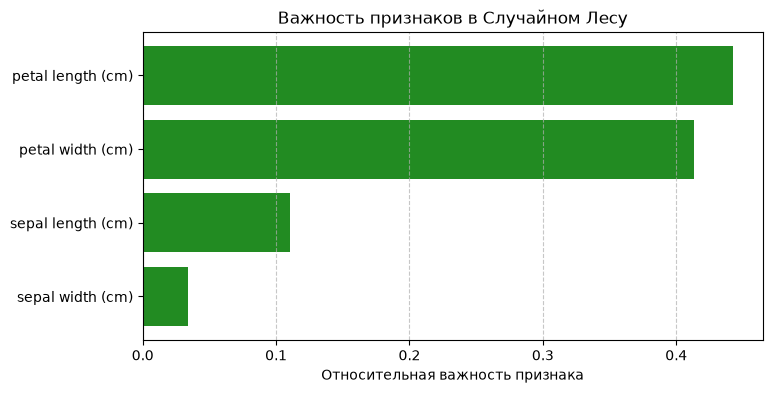

In [11]:
forest_clf = RandomForestClassifier(n_estimators=500, random_state=42, n_jobs=-1)
forest_clf.fit(X_train_i, y_train_i)

y_pred_forest = forest_clf.predict(X_test_i)
print(f"Точность случайного леса: {accuracy_score(y_test_i, y_pred_forest):.2%}\n")

importances = forest_clf.feature_importances_
feature_names = iris.feature_names

indices = np.argsort(importances)

plt.figure(figsize=(8, 4))
plt.barh(range(len(indices)), importances[indices], color='forestgreen', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Относительная важность признака')
plt.title('Важность признаков в Случайном Лесу')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

In [13]:
ada_clf = AdaBoostClassifier(
    DecisionTreeClassifier(max_depth=1), n_estimators = 200,
    learning_rate = 0.5, random_state=42
)

ada_clf.fit(X_train, y_train)

y_pred_ada = ada_clf.predict(X_test)
print(f"Точность алгоритма AdaBoost на полумесяцах: {accuracy_score(y_test, y_pred_ada):.2%}")

Точность алгоритма AdaBoost на полумесяцах: 89.00%


Минимум ошибки на валидации достигнут при n_estimators = 37


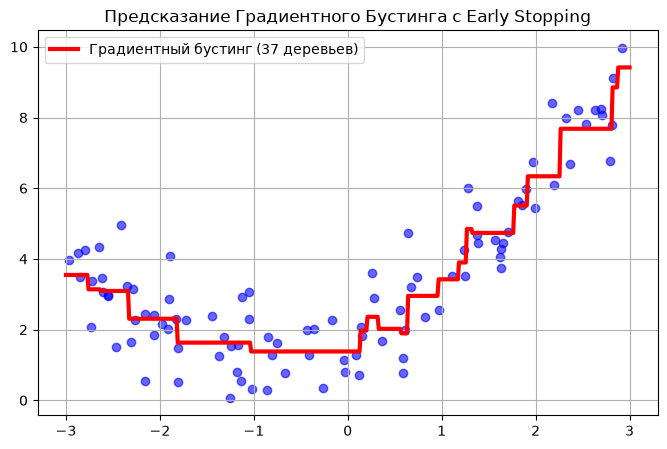

In [17]:
np.random.seed(42)
X_g = np.random.rand(100, 1) * 6 - 3
y_g = 0.5 * X_g**2 + X_g + 2 + np.random.randn(100, 1)
X_train_g, X_val_g, y_train_g, y_val_g = train_test_split(X_g, y_g, test_size=0.2, random_state=42)

gbrt = GradientBoostingRegressor(max_depth=2, n_estimators=120, learning_rate=0.1, random_state=42)
gbrt.fit(X_train_g, y_train_g.ravel())

errors = [mean_squared_error(y_val_g, y_pred) for y_pred in gbrt.staged_predict(X_val_g)]
bst_n_estimators = np.argmin(errors) + 1

gbrt_best = GradientBoostingRegressor(max_depth=2, n_estimators=bst_n_estimators, learning_rate=0.1, random_state=42)
gbrt_best.fit(X_train_g, y_train_g.ravel())

print(f"Минимум ошибки на валидации достигнут при n_estimators = {bst_n_estimators}")

X_grid = np.linspace(-3, 3, 500).reshape(-1, 1)
y_pred_best = gbrt_best.predict(X_grid)

plt.figure(figsize=(8, 5))
plt.scatter(X_g, y_g, color="blue", alpha=0.6)
plt.plot(X_grid, y_pred_best, "r-", linewidth=3, label=f"Градиентный бустинг ({bst_n_estimators} деревьев)")
plt.title("Предсказание Градиентного Бустинга с Early Stopping")
plt.legend()
plt.grid(True)
plt.show()
